## mlpi26_Lect08_nbsup1.ipynb

# Lecture 8 Supplement 1 :The mechanics of PyTorch — an AGV fleet case study

**Companion notebook to the lecture *Going deeper: the mechanics of PyTorch*.**

Everything in this notebook runs on CPU in about six minutes and downloads nothing.
The data is synthetic but generated from real vehicle physics, so the feature names, the
units and the shape of the nonlinearity are the ones you would meet on a real warehouse
fleet.

## The running example

A fleet of **automated guided vehicles (AGVs)** in a warehouse. Two questions the fleet
controller has to answer, which between them exercise every mechanism in this lecture:

| | question | task | why it is here |
|---|---|---|---|
| **Q1** | Given the pose error on final approach, will the vehicle dock or miss? | binary classification, 2 inputs | the decision boundary is **XOR-shaped**, so it exposes *model capacity* |
| **Q2** | How many watt-hours will this transport job draw from the battery? | regression, 7 raw columns | the columns are **mixed types**, so it exposes *feature columns* and the end-to-end workflow |

## Learning objectives

By the end you should be able to:

1. Explain what PyTorch records when you run a line of tensor arithmetic, and what
   `loss.backward()` then does with it.
2. Tell a leaf tensor from a non-leaf one, and say which of them ends up with a `.grad`.
3. Derive a gradient by hand for a one-neuron model and check it against autograd.
4. Decide between `nn.Sequential` and a subclass of `nn.Module`, and justify the choice.
5. Diagnose a capacity failure (as opposed to an optimisation failure) from the learning curves.
6. Write a custom layer that behaves differently during training and inference.
7. Turn continuous, ordinal and nominal columns into one input tensor without leaking
   information from the test set.

## Prerequisites

Tensors, `Dataset`/`DataLoader`, and the basic training loop from the previous lecture;
partial derivatives and the chain rule; `numpy` and `pandas` basics.


---
## 0. Environment

Pin the versions in your notes: PyTorch's API is stable but not frozen, and a notebook that
records what it ran under is a notebook you can debug six months later.


In [1]:
import sys, platform
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

print("python      ", sys.version.split()[0], "on", platform.system())
print("torch       ", torch.__version__)
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", matplotlib.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device      ", DEVICE)


python       3.11.15 on Linux
torch        2.14.0+cu130
numpy        2.4.4
pandas       3.0.2
matplotlib   3.10.9
CUDA available: False
device       cpu

In [2]:
# one plotting style for the whole notebook
SURF, INK2, GRID = "#fcfcfb", "#52514e", "#e1e0d9"
BLUE, ORANGE, AQUA, YELLOW, VIOLET, MUTED = ("#2a78d6", "#eb6834", "#1baf7a",
                                             "#eda100", "#4a3aa7", "#898781")
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.size": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "lines.linewidth": 1.8,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)


---
## 1. The data

Both datasets are generated here so the notebook is self-contained. Read the generators —
knowing exactly what mechanism produced the labels is what lets us say later whether a
model *should* have been able to fit them.

### 1a. Docking: pose errors on the final approach

An AGV closing on a conveyor dock has two pose errors left when it enters the final straight:

* `x1` — **lateral offset** of the vehicle centre from the dock centreline, in units of the
  50 mm tolerance (positive = vehicle sits to the right of the line);
* `x2` — **heading error**, in units of the 4° tolerance (positive = nose points right).

A differential-drive AGV on a short final straight can correct one error, not both. If the
nose points *back toward* the centreline the two errors cancel and the vehicle docks; if it
points *further away* they compound and it clips the frame. So

$$\text{dock\_ok} = 1 \iff \operatorname{sign}(x_1) \neq \operatorname{sign}(x_2)$$

which is exactly **XOR**. This is the textbook XOR problem with a mechanism attached, and
it is the cleanest way to see what "model capacity" means.


In [3]:
def make_docking_data(n=600, seed=7):
    '''Final-approach pose errors of an AGV. Label 1 = the vehicle docks.'''
    rng = np.random.default_rng(seed)
    x = rng.uniform(low=-1.0, high=1.0, size=(n, 2))
    y = (x[:, 0] * x[:, 1] < 0).astype(np.float32)
    return x.astype(np.float32), y

x_dock, y_dock = make_docking_data()
N_TRAIN = 300
x_train = torch.tensor(x_dock[:N_TRAIN]);  y_train = torch.tensor(y_dock[:N_TRAIN])
x_valid = torch.tensor(x_dock[N_TRAIN:]);  y_valid = torch.tensor(y_dock[N_TRAIN:])

print("train", tuple(x_train.shape), " valid", tuple(x_valid.shape))
print(f"share that dock — train {y_train.mean():.3f}   valid {y_valid.mean():.3f}")
print("so 'always predict docks' already scores %.1f %% on the validation set"
      % (100 * y_valid.mean()))


train (300, 2)  valid (300, 2)
share that dock — train 0.527   valid 0.543
so 'always predict docks' already scores 54.3 % on the validation set

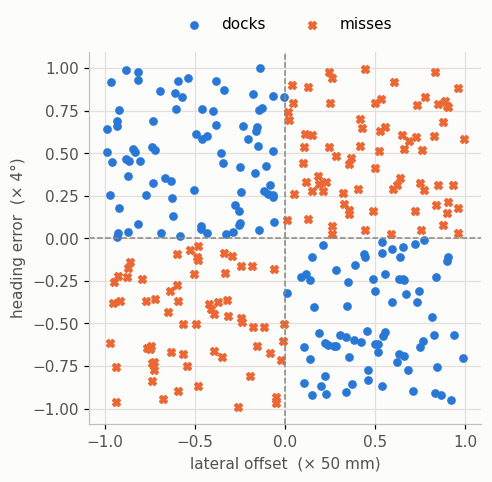

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
xn, yn = x_train.numpy(), y_train.numpy()
ax.scatter(xn[yn == 1, 0], xn[yn == 1, 1], s=22, c=BLUE, marker="o", label="docks")
ax.scatter(xn[yn == 0, 0], xn[yn == 0, 1], s=26, c=ORANGE, marker="X", label="misses")
ax.axhline(0, color=MUTED, lw=1, ls="--"); ax.axvline(0, color=MUTED, lw=1, ls="--")
ax.set_xlabel("lateral offset  (× 50 mm)"); ax.set_ylabel("heading error  (× 4°)")
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.13))
plt.show()


Look at the four quadrants. Any straight line you draw puts two same-coloured quadrants on
opposite sides of it. Hold on to that picture — in section 5 a model with 3 parameters will
fail on exactly this, and the learning curve will tell us *why* it failed.

### 1b. Fleet energy: one row per transport job

Energy drawn from the pack over a job, built from textbook vehicle dynamics:

$$E \;=\; \frac{W_{\text{roll}} + W_{\text{grade}} + W_{\text{accel}}}{\eta_{\text{drive}}\,(1-\text{age loss})} \;+\; P_{\text{aux}}\,\frac{d}{v}$$

The pieces that matter for the modelling:

* **mass** is tare (set by `vehicle_model`) plus `payload_kg`, and it multiplies the rolling,
  gravity and acceleration terms — every one of those is a *product* of two features;
* **downhill** returns only 25 % of the gravity energy through regeneration, so the grade term
  is **kinked at zero**;
* **auxiliaries** (controller, lidar, safety scanners) burn a constant 95 W for the duration
  of the trip, so their cost goes as $d/v$ — a slow trip costs *more*, which is the opposite
  of what a linear model expects;
* **battery age** enters through four discrete resistance bands, not smoothly.

None of those four are linear in the raw columns. That is why the least-squares baseline in
section 9 loses so badly, and it is not a rigged fight — it is what real energy data does.


In [5]:
G = 9.81
FLOORS = ["epoxy", "sealed_concrete", "steel_grating"]
CRR    = {"epoxy": 0.011, "sealed_concrete": 0.017, "steel_grating": 0.026}
MODELS = ["T2_tugger", "T4_pallet", "H6_heavy"]
TARE_KG     = {"T2_tugger": 320.0, "T4_pallet": 520.0, "H6_heavy": 980.0}
DRIVE_EFF   = {"T2_tugger": 0.84,  "T4_pallet": 0.86,  "H6_heavy": 0.89}
MAX_PAYLOAD = {"T2_tugger": 250.0, "T4_pallet": 800.0, "H6_heavy": 1800.0}

AGE_BOUNDARIES = [12.0, 30.0, 48.0]            # months -> 4 bands
AGE_LOSS       = [0.01, 0.04, 0.09, 0.16]      # extra draw from cell resistance
P_AUX_W, REGEN_FRACTION, STOP_SPACING_M = 95.0, 0.25, 110.0


def make_fleet_data(n=5000, seed=7, noise=0.035):
    '''One row per AGV transport job; target is energy drawn from the pack, in Wh.'''
    rng = np.random.default_rng(seed)
    model = rng.choice(MODELS, size=n, p=[0.35, 0.45, 0.20])
    tare      = np.array([TARE_KG[m] for m in model])
    eff_drive = np.array([DRIVE_EFF[m] for m in model])
    pay_max   = np.array([MAX_PAYLOAD[m] for m in model])

    payload  = rng.uniform(0.0, 1.0, size=n) ** 1.3 * pay_max
    speed    = rng.uniform(0.45, 1.95, size=n)
    grade    = rng.normal(0.0, 1.8, size=n).clip(-4.5, 4.5)
    distance = rng.uniform(25.0, 420.0, size=n)
    floor    = rng.choice(FLOORS, size=n, p=[0.5, 0.35, 0.15])
    crr      = np.array([CRR[f] for f in floor])
    age      = rng.uniform(0.0, 60.0, size=n)

    mass, theta = tare + payload, np.arctan(grade / 100.0)
    w_roll  = crr * mass * G * np.cos(theta) * distance
    w_g_raw = mass * G * np.sin(theta) * distance
    w_grade = np.where(w_g_raw > 0, w_g_raw, REGEN_FRACTION * w_g_raw)
    n_stops = 1.0 + distance / STOP_SPACING_M
    w_accel = 0.5 * mass * speed ** 2 * n_stops * (1.0 - REGEN_FRACTION)
    w_aux   = P_AUX_W * distance / speed

    eff = eff_drive * (1.0 - np.array(AGE_LOSS)[np.digitize(age, AGE_BOUNDARIES)])
    energy_wh = ((w_roll + w_grade + w_accel) / eff + w_aux) / 3600.0
    energy_wh = energy_wh * (1.0 + noise * rng.standard_normal(n))

    return pd.DataFrame({
        "payload_kg": payload.round(1), "speed_mps": speed.round(3),
        "grade_pct": grade.round(3), "distance_m": distance.round(1),
        "battery_age_months": age.round(1), "floor_type": floor,
        "vehicle_model": model, "energy_wh": energy_wh.round(3)})


fleet = make_fleet_data()
fleet.head()


   payload_kg  speed_mps  grade_pct  distance_m  battery_age_months       floor_type vehicle_model  energy_wh
0       364.7      1.238     -0.666       376.1                39.8            epoxy     T4_pallet     18.428
1      1591.2      1.901     -0.327       352.4                42.3    steel_grating      H6_heavy     86.351
2       411.8      1.665     -2.126        90.1                58.8  sealed_concrete     T4_pallet      5.405
3        53.4      1.169     -3.198        81.7                45.6  sealed_concrete     T2_tugger      2.888
4       146.5      0.721     -0.674       285.6                55.0    steel_grating     T2_tugger     21.556

In [6]:
print(fleet.dtypes, "\n")
print(fleet["energy_wh"].describe().round(2))


payload_kg            float64
speed_mps             float64
grade_pct             float64
distance_m            float64
battery_age_months    float64
floor_type                str
vehicle_model             str
energy_wh             float64
dtype: object 

count    5000.00
mean       20.44
std        18.77
min         0.76
25%         8.28
50%        15.42
75%        26.05
max       219.89
Name: energy_wh, dtype: float64

---
## 2. PyTorch's computation graph

PyTorch evaluates expressions on a **directed acyclic graph** whose nodes are operations and
whose edges are tensors. The graph is *dynamic*: it is recorded as your Python runs, one
operation at a time, and discarded after `backward()`. That is what lets you put `if`, `for`
and `print` inside a model and still debug it line by line.

Build the traction-work part of the energy model as a plain Python function.


In [7]:
def traction_work(f_roll, f_grade, distance):
    '''W = (F_roll + F_grade) * d  -- three tensors in, one out.'''
    r1 = torch.add(f_roll, f_grade)
    r2 = torch.mul(r1, distance)
    return r2


# rank 0 (scalars): one job
print("rank 0:", traction_work(torch.tensor(58.0), torch.tensor(12.0), torch.tensor(140.0)))

# rank 1: a batch of three jobs, no change to the function
print("rank 1:", traction_work(torch.tensor([58., 61., 44.]),
                               torch.tensor([12., -9., 3.]),
                               torch.tensor([140., 210., 95.])))

# rank 2: the same three jobs as a column vector -- broadcasting still works
print("rank 2:", traction_work(torch.tensor([[58.], [61.], [44.]]),
                               torch.tensor([[12.], [-9.], [3.]]),
                               torch.tensor([[140.], [210.], [95.]])).T)


rank 0: tensor(9800.)
rank 1: tensor([ 9800., 10920.,  4465.])
rank 2: tensor([[ 9800., 10920.,  4465.]])

Two things to notice.

**The graph is built, not declared.** There is no `session`, no `compile` step, no
placeholder. `torch.add` runs immediately *and* records a node. You can therefore print an
intermediate tensor, or branch on its value, inside the model.

**Dynamic means Python control flow is allowed.** The next cell decides how many
regeneration stages to apply based on the *value* of the grade, which a static graph could
not express without special operators.


In [8]:
def regen_chain(work, grade_pct):
    '''Apply one recovery stage per 2 % of downhill grade -- a Python loop in the graph.'''
    stages = int(abs(grade_pct.item()) // 2) if grade_pct.item() < 0 else 0
    for _ in range(stages):
        work = work * 0.75
    return work, stages


for g in (-5.0, -1.0, 3.0):
    w, s = regen_chain(torch.tensor(1000.0), torch.tensor(g))
    print(f"grade {g:+5.1f} %  ->  {s} regen stage(s), work = {w.item():7.1f} J")


grade  -5.0 %  ->  2 regen stage(s), work =   562.5 J
grade  -1.0 %  ->  0 regen stage(s), work =  1000.0 J
grade  +3.0 %  ->  0 regen stage(s), work =  1000.0 J

---
## 3. Tensors that store model parameters

Four attributes decide what a tensor can do in a model:

| attribute | what it controls | the mistake it causes |
|---|---|---|
| `shape` | which operations line up | `mat1 and mat2 shapes cannot be multiplied` |
| `dtype` | precision, and whether gradients are even possible | `Only Tensors of floating point ... can require gradients` |
| `device` | where the arithmetic happens | `Expected all tensors to be on the same device` |
| `requires_grad` | whether a graph is recorded through it | silently no `.grad`, so the optimiser does nothing |

A tensor you created yourself with `requires_grad=True` is a **leaf**. Anything computed from
it is a **non-leaf** and carries a `grad_fn`. Only leaves keep a `.grad` after `backward()`.


In [9]:
w = torch.tensor([[0.8], [-0.5]], requires_grad=True)   # a leaf: a parameter
x = torch.tensor([[0.6, -0.4]])                          # data: no gradient needed
z = x @ w                                                # non-leaf: has a grad_fn

for name, t in (("w", w), ("x", x), ("z", z)):
    print(f"{name}: shape {tuple(t.shape)}  dtype {t.dtype}  requires_grad "
          f"{t.requires_grad}  is_leaf {t.is_leaf}  grad_fn {t.grad_fn}")


w: shape (2, 1)  dtype torch.float32  requires_grad True  is_leaf True  grad_fn None
x: shape (1, 2)  dtype torch.float32  requires_grad False  is_leaf True  grad_fn None
z: shape (1, 1)  dtype torch.float32  requires_grad True  is_leaf False  grad_fn <MmBackward0 object at 0x7f48880bbf40>

In [10]:
# requires_grad is False by default and can be switched on in place
v = torch.tensor([1.0, 2.0, 3.0])
print("before:", v.requires_grad)
v.requires_grad_()            # the trailing underscore means 'in place'
print("after :", v.requires_grad)

# integers cannot require gradients -- this is the error you will hit with label tensors
try:
    torch.tensor([1, 2, 3]).requires_grad_()
except RuntimeError as e:
    print("\nRuntimeError:", e)


before: False
after : True

RuntimeError: only Tensors of floating point dtype can require gradients

### Initialisation: why not zeros, and why not anything

Initialising every weight to the same value leaves the hidden units symmetric — they receive
identical gradients forever and the network never becomes more expressive than one unit.
Random is necessary; *scale* is what Glorot (Xavier) initialisation fixes. Drawing weights
with variance $2/(n_{in}+n_{out})$ keeps the variance of activations and of gradients roughly
constant from layer to layer, so deep stacks neither saturate nor vanish.

$$W \sim \text{Uniform}\!\left(-\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}},\;
\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}\right)
\qquad\text{or}\qquad
\sigma = \frac{\sqrt 2}{\sqrt{n_{in}+n_{out}}}$$


In [11]:
torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print("xavier_normal_:\n", w)

limit = (6.0 / (2 + 3)) ** 0.5
print(f"\nuniform limit for a 2x3 layer: ±{limit:.4f}")
print("std of a 512x512 xavier-normal draw:",
      round(float(nn.init.xavier_normal_(torch.empty(512, 512)).std()), 4),
      " (theory:", round((2 / (512 + 512)) ** 0.5, 4), ")")


xavier_normal_:
 tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])

uniform limit for a 2x3 layer: ±1.0954
std of a 512x512 xavier-normal draw: 0.0442  (theory: 0.0442 )

In [12]:
class TwoWeights(nn.Module):
    '''Parameters declared by hand -- this is what nn.Linear does for you.'''
    def __init__(self):
        super().__init__()
        self.w1 = nn.Parameter(nn.init.xavier_normal_(torch.empty(2, 8)))
        self.w2 = nn.Parameter(nn.init.xavier_normal_(torch.empty(8, 1)))

m = TwoWeights()
for name, p in m.named_parameters():
    print(f"{name:4s} shape {tuple(p.shape)}  requires_grad {p.requires_grad}")
print("total parameters:", sum(p.numel() for p in m.parameters()))


w1   shape (2, 8)  requires_grad True
w2   shape (8, 1)  requires_grad True
total parameters: 24

> **`nn.Parameter` vs a plain tensor.** Wrapping a tensor in `nn.Parameter` registers it with
> the module, so it appears in `model.parameters()` and therefore reaches the optimiser, and
> it moves with `model.to(device)` and saves with `state_dict()`. A bare tensor attribute with
> `requires_grad=True` does none of that: it will accumulate gradients that nobody applies.
> This is one of the most common "my loss doesn't move" bugs.


---
## 4. Automatic differentiation

Take the smallest possible docking model: one neuron, two weights and a bias, trained with
binary cross-entropy.

$$z = w_1x_1 + w_2x_2 + b,\qquad p=\sigma(z),\qquad
L = -\big[y\log p + (1-y)\log(1-p)\big]$$

The classic result for this pair is that the sigmoid and the cross-entropy cancel:

$$\frac{\partial L}{\partial z} = p - y
\qquad\Rightarrow\qquad
\frac{\partial L}{\partial w_j} = (p-y)\,x_j,
\qquad
\frac{\partial L}{\partial b} = p-y$$

Let us check that PyTorch agrees, to the last bit.


In [13]:
x = torch.tensor([[0.6, -0.4]])     # one approach: right of the line, nose pointing left
y = torch.tensor([1.0])             # it docked
w = torch.tensor([[0.8], [-0.5]], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)

z    = x @ w + b
p    = torch.sigmoid(z)[:, 0]
loss = nn.BCELoss()(p, y)
loss.backward()

dz = (p - y).detach()               # the analytic dL/dz
print(f"p = {p.item():.6f}   loss = {loss.item():.6f}\n")
print("dL/dw  autograd:", w.grad.flatten().tolist())
print("dL/dw  by hand  :", (x.T * dz).flatten().tolist())
print("dL/db  autograd:", b.grad.tolist())
print("dL/db  by hand  :", dz.tolist())
print("\nmax |difference| =",
      max(float((w.grad.flatten() - (x.T * dz).flatten()).abs().max()),
          float((b.grad - dz).abs().max())))


p = 0.685680   loss = 0.377344

dL/dw  autograd: [-0.18859191238880157, 0.12572793662548065]
dL/dw  by hand  : [-0.18859191238880157, 0.12572793662548065]
dL/db  autograd: [-0.3143198490142822]
dL/db  by hand  : [-0.3143198490142822]

max |difference| = 0.0

### Reverse accumulation, and why it is the cheap direction

For a chain $y=f(g(h(x)))$ the derivative can be accumulated from either end:

* **forward**: $\frac{dy}{dx}=\frac{du_3}{du_2}\frac{du_2}{du_1}\frac{du_1}{dx}$ — cheap when
  there are few *inputs*;
* **reverse**: $\frac{dy}{dx}=\frac{dy}{du_1}\frac{du_1}{dx}$, starting from the output —
  cheap when there are few *outputs*.

A neural network has millions of inputs (the weights) and exactly one output (the scalar
loss), so reverse accumulation wins by a factor of millions. That is what `backward()` does,
and it is why the loss must be a **scalar** before you call it.


In [14]:
# backward() on a non-scalar needs to be told what to weight the outputs by
v = torch.tensor([2.0, 3.0], requires_grad=True)
out = v * v                      # shape (2,), not a scalar
try:
    out.backward()
except RuntimeError as e:
    print("RuntimeError:", str(e).splitlines()[0])

out.backward(torch.ones_like(out))   # equivalent to out.sum().backward()
print("d(sum v^2)/dv =", v.grad.tolist(), " (expected [4.0, 6.0])")


RuntimeError: grad can be implicitly created only for scalar outputs
d(sum v^2)/dv = [4.0, 6.0]  (expected [4.0, 6.0])

### Three habits that prevent most autograd bugs

1. **Gradients accumulate.** `.grad` is *added to*, never overwritten. This is deliberate — it
   lets you split a large batch across several backward passes — but it means you must call
   `optimizer.zero_grad()` (or `model.zero_grad()`) once per step, or every step is
   contaminated by the previous one.
2. **Wrap evaluation in `torch.no_grad()`.** No graph is recorded, so it is faster and uses
   less memory. Forgetting it on a validation loop is a classic out-of-memory cause.
3. **`.detach()` to take a value out of the graph**, e.g. for logging or for a target you do
   not want gradients to flow through.


In [15]:
w = torch.tensor([1.0], requires_grad=True)
for step in range(3):
    loss = (3.0 * w) ** 2
    loss.backward()
    print(f"step {step}: w.grad = {w.grad.item():6.1f}   <- accumulating, never reset")

w.grad.zero_()
for step in range(3):
    loss = (3.0 * w) ** 2
    loss.backward()
    print(f"step {step}: w.grad = {w.grad.item():6.1f}   <- correct, reset each step")
    w.grad.zero_()


step 0: w.grad =   18.0   <- accumulating, never reset
step 1: w.grad =   36.0   <- accumulating, never reset
step 2: w.grad =   54.0   <- accumulating, never reset
step 0: w.grad =   18.0   <- correct, reset each step
step 1: w.grad =   18.0   <- correct, reset each step
step 2: w.grad =   18.0   <- correct, reset each step

In [16]:
xv = torch.tensor([[0.6, -0.4]])
lin = nn.Linear(2, 1)

out_train = lin(xv)
with torch.no_grad():
    out_eval = lin(xv)

print("inside the graph :", out_train.requires_grad, out_train.grad_fn)
print("under no_grad    :", out_eval.requires_grad, out_eval.grad_fn)
print("detached         :", out_train.detach().requires_grad)


inside the graph : True <AddmmBackward0 object at 0x7f48880af7c0>
under no_grad    : False None
detached         : False

---
## 5. `nn.Sequential`, and the loss / optimizer pair

`nn.Sequential` chains modules in the order you list them. It is the right tool whenever the
data flows in one straight line, which covers most feedforward models.


In [17]:
torch.manual_seed(1)
model = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 8), nn.ReLU(),
    nn.Linear(8, 1), nn.Sigmoid(),
)
model


Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)

In [18]:
# layers are indexable, so you can initialise or regularise them individually
nn.init.xavier_uniform_(model[0].weight)
nn.init.zeros_(model[0].bias)

l1_lambda = 1e-3
l1_penalty = l1_lambda * model[2].weight.abs().sum()
print("L1 penalty on the second Linear:", round(l1_penalty.item(), 6))
print("(add it to the loss before backward(); for L2 use weight_decay in the optimizer)")
print("\nparameters:", sum(p.numel() for p in model.parameters()))


L1 penalty on the second Linear: 0.011718
(add it to the loss before backward(); for L2 use weight_decay in the optimizer)

parameters: 105

**Choosing a loss.** The task decides, not taste:

| task | last layer | loss | note |
|---|---|---|---|
| regression | plain `Linear`, no activation | `nn.MSELoss` (or `nn.L1Loss` if outliers matter) | MSE is in *squared* target units |
| binary classification | `Sigmoid` | `nn.BCELoss` | |
| binary classification | none (logits) | `nn.BCEWithLogitsLoss` | **preferred** — numerically stable |
| multi-class | none (logits) | `nn.CrossEntropyLoss` | it applies log-softmax itself; do **not** add a Softmax layer |

```python
# WRONG -- softmax applied twice, gradients get squashed
model = nn.Sequential(nn.Linear(16, 3), nn.Softmax(dim=1))
loss_fn = nn.CrossEntropyLoss()

# RIGHT -- let the loss do it
model = nn.Sequential(nn.Linear(16, 3))
loss_fn = nn.CrossEntropyLoss()
```

**Choosing an optimizer.** `SGD` with a hand-tuned learning rate, or `Adam` when you would
rather not tune one. We use plain `SGD` for the docking problem (it is tiny and it makes the
capacity argument cleaner) and `Adam` for the fleet regression.


---
## 6. Model capacity: the docking problem

Now the experiment that the whole lecture turns on. Same data, same loss, same optimizer,
same number of epochs — only the architecture changes.


In [19]:
def train_dock(model, epochs=400, lr=0.05, batch_size=4, seed=1, noisy=False):
    '''Train a docking classifier; return the per-epoch history.'''
    loss_fn   = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    g = torch.Generator().manual_seed(seed)          # reproducible shuffling
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size,
                        shuffle=True, generator=g)

    hist = {k: [] for k in ("loss_tr", "acc_tr", "loss_va", "acc_va")}
    for _ in range(epochs):
        run_loss = run_acc = 0.0
        for xb, yb in loader:
            pred = model(xb, True)[:, 0] if noisy else model(xb)[:, 0]
            loss = loss_fn(pred, yb)
            loss.backward()                 # accumulate gradients
            optimizer.step()                # apply them
            optimizer.zero_grad()           # clear them for the next batch
            run_loss += loss.item() * xb.size(0)
            run_acc  += ((pred >= 0.5).float() == yb).float().sum().item()
        hist["loss_tr"].append(run_loss / len(y_train))
        hist["acc_tr"].append(run_acc / len(y_train))
        with torch.no_grad():                        # no graph for evaluation
            pv = model(x_valid)[:, 0]
            hist["loss_va"].append(loss_fn(pv, y_valid).item())
            hist["acc_va"].append(((pv >= 0.5).float() == y_valid).float().mean().item())
    return hist


def build_dock_model(hidden):
    layers, prev = [], 2
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    return nn.Sequential(*layers, nn.Linear(prev, 1), nn.Sigmoid())


print("helpers defined")


helpers defined

In [20]:
torch.manual_seed(1)
flat = build_dock_model([])                 # logistic regression: 3 parameters
hist_flat = train_dock(flat)

torch.manual_seed(1)
deep = build_dock_model([8, 8])             # two hidden layers: 105 parameters
hist_deep = train_dock(deep)

print(f"no hidden layer  : train {hist_flat['acc_tr'][-1]:.3f}  "
      f"valid {hist_flat['acc_va'][-1]:.3f}  final loss {hist_flat['loss_va'][-1]:.4f}")
print(f"two hidden layers: train {hist_deep['acc_tr'][-1]:.3f}  "
      f"valid {hist_deep['acc_va'][-1]:.3f}  final loss {hist_deep['loss_va'][-1]:.4f}")
print(f"\nln 2 = {np.log(2):.4f}  <- the loss of a model that has learned nothing")


no hidden layer  : train 0.603  valid 0.610  final loss 0.6978
two hidden layers: train 0.987  valid 0.973  final loss 0.0703

ln 2 = 0.6931  <- the loss of a model that has learned nothing

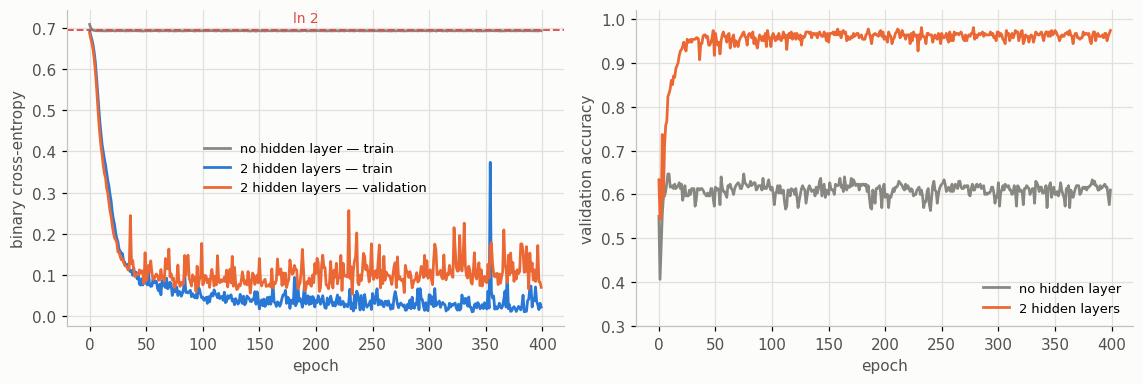

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].plot(hist_flat["loss_tr"], color=MUTED, label="no hidden layer — train")
axes[0].plot(hist_deep["loss_tr"], color=BLUE, label="2 hidden layers — train")
axes[0].plot(hist_deep["loss_va"], color=ORANGE, label="2 hidden layers — validation")
axes[0].axhline(np.log(2), color="#e34948", lw=1.2, ls="--")
axes[0].text(180, np.log(2) + 0.02, "ln 2", color="#e34948", fontsize=9)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("binary cross-entropy")
axes[0].legend(fontsize=8.5)

axes[1].plot(hist_flat["acc_va"], color=MUTED, label="no hidden layer")
axes[1].plot(hist_deep["acc_va"], color=ORANGE, label="2 hidden layers")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation accuracy"); axes[1].set_ylim(.3, 1.02)
axes[1].legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()


### Reading the diagnosis off the curves

This is the skill worth carrying away, because it tells you what to change next:

| what you see | what it means | what to do |
|---|---|---|
| train loss flat and **high** (here: pinned at ln 2 ≈ 0.693) | **underfitting / too little capacity** — the model cannot represent the function | add width or depth; add features |
| train loss low, validation loss rising | **overfitting** | more data, regularisation, early stopping |
| both low and together | fit is as good as the noise allows | stop; more data will not help |
| loss jumps around or diverges | learning rate too high, or `zero_grad()` missing | lower `lr`; check the loop |

The flat model sits in row one for all 400 epochs. **No amount of further training fixes a
capacity problem** — that is the whole point of the experiment.

### The capacity ladder

How much model do we actually need? Three seeds per architecture, because a small network on
a small dataset is seed-sensitive and a single run would mislead you.


In [22]:
ladder = []
for name, hidden in (("no hidden layer", []), ("1 hidden, 4 units", [4]),
                     ("1 hidden, 8 units", [8]), ("2 hidden, 8 units", [8, 8])):
    accs = []
    for sd in (1, 2, 3):
        torch.manual_seed(sd)
        m = build_dock_model(hidden)
        accs.append(train_dock(m, seed=sd)["acc_va"][-1])
    ladder.append((name, sum(p.numel() for p in m.parameters()),
                   float(np.mean(accs)), float(np.min(accs)), float(np.max(accs))))

print(f"{'architecture':<20}{'params':>7}{'mean acc':>10}{'min':>8}{'max':>8}")
for name, npar, mean, lo, hi in ladder:
    print(f"{name:<20}{npar:>7}{mean:>10.3f}{lo:>8.3f}{hi:>8.3f}")


architecture         params  mean acc     min     max
no hidden layer           3     0.590   0.563   0.610
1 hidden, 4 units        17     0.921   0.820   0.973
1 hidden, 8 units        33     0.939   0.863   0.977
2 hidden, 8 units       105     0.972   0.970   0.973

One hidden layer is already enough to bend the boundary — that is the **universal
approximation theorem** in action: a single hidden layer with enough units can approximate
any continuous function on a bounded region. Going deeper rather than wider buys the same
accuracy with a steadier result across seeds (look at the min/max spread), which is the usual
practical argument for depth: fewer parameters for the same capacity. The cost of depth is
that gradients have further to travel, which is where vanishing and exploding gradients come
from.


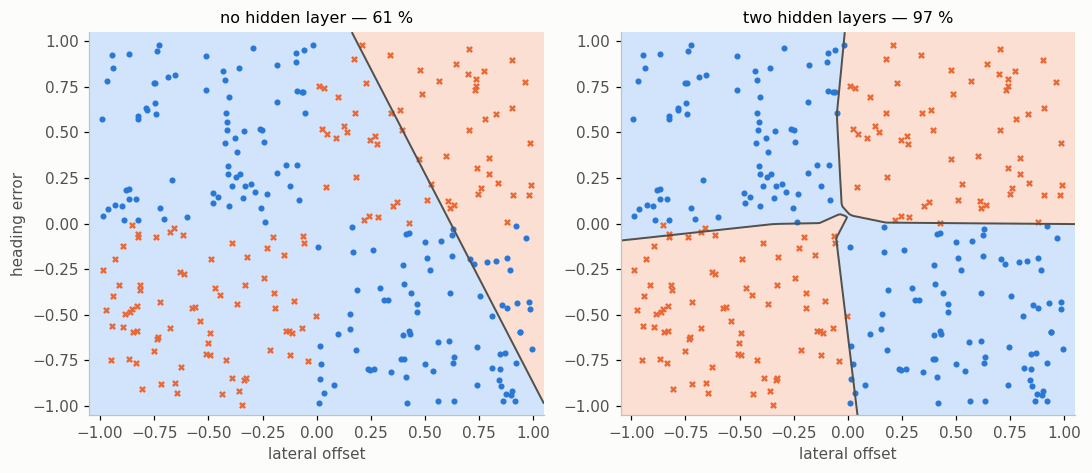

In [23]:
def plot_regions(models, titles):
    grid = np.linspace(-1.05, 1.05, 220)
    XX, YY = np.meshgrid(grid, grid)
    pts = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)
    fig, axes = plt.subplots(1, len(models), figsize=(5.0 * len(models), 4.4))
    axes = np.atleast_1d(axes)
    for ax, m, t in zip(axes, models, titles):
        with torch.no_grad():
            p = m(pts)[:, 0].numpy().reshape(XX.shape)
        ax.contourf(XX, YY, p, levels=[0, .5, 1], colors=["#fbdcce", "#cde2fb"], alpha=.9)
        ax.contour(XX, YY, p, levels=[.5], colors=["#52514e"], linewidths=1.3)
        xn2, yn2 = x_valid.numpy(), y_valid.numpy()
        ax.scatter(xn2[yn2 == 1, 0], xn2[yn2 == 1, 1], s=16, c=BLUE, marker="o", lw=0)
        ax.scatter(xn2[yn2 == 0, 0], xn2[yn2 == 0, 1], s=20, c=ORANGE, marker="X", lw=0)
        ax.set_title(t, fontsize=10.5); ax.set_xlabel("lateral offset"); ax.grid(False)
    axes[0].set_ylabel("heading error")
    plt.tight_layout(); plt.show()


plot_regions([flat, deep],
             [f"no hidden layer — {hist_flat['acc_va'][-1]*100:.0f} %",
              f"two hidden layers — {hist_deep['acc_va'][-1]*100:.0f} %"])


---
## 7. `nn.Module` when `Sequential` is not enough

`Sequential` can only express a single chain. As soon as the data has to branch, rejoin, be
reused, or flow differently in training than in inference, you subclass `nn.Module` and write
`forward()` yourself.

The contract is small:

* `__init__` declares the sub-modules and parameters as attributes (that is what registers
  them);
* `forward(x)` says how the data flows;
* you never call `forward` directly — call the module, `model(x)`, so that hooks and
  train/eval bookkeeping run.


In [24]:
class DockNet(nn.Module):
    '''The same architecture as `deep`, written as a module, plus a predict() helper.'''
    def __init__(self, hidden=8):
        super().__init__()
        self.l1, self.a1 = nn.Linear(2, hidden), nn.ReLU()
        self.l2, self.a2 = nn.Linear(hidden, hidden), nn.ReLU()
        self.l3, self.a3 = nn.Linear(hidden, 1), nn.Sigmoid()

    def forward(self, x):
        x = self.a1(self.l1(x))
        x = self.a2(self.l2(x))
        return self.a3(self.l3(x))

    def predict(self, x):
        '''Class labels for a numpy array -- the interface the fleet controller wants.'''
        x = torch.as_tensor(x, dtype=torch.float32)
        with torch.no_grad():
            return (self.forward(x)[:, 0] >= 0.5).float()


torch.manual_seed(1)
net = DockNet()
print(net)
print("\nsame parameter count as the Sequential version:",
      sum(p.numel() for p in net.parameters()))

hist_net = train_dock(net)
print(f"trained: valid accuracy {hist_net['acc_va'][-1]:.3f}"
      "  (same result as the Sequential version, as it must be)")

# right of the centreline, nose pointing back to it -> should dock
# right of the centreline, nose pointing further right -> should miss
approaches = np.array([[0.7, -0.6], [0.7, 0.6]], dtype=np.float32)
print("predict:", net.predict(approaches).tolist(), " (expected [1.0, 0.0])")


DockNet(
  (l1): Linear(in_features=2, out_features=8, bias=True)
  (a1): ReLU()
  (l2): Linear(in_features=8, out_features=8, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=8, out_features=1, bias=True)
  (a3): Sigmoid()
)

same parameter count as the Sequential version: 105
trained: valid accuracy 0.973  (same result as the Sequential version, as it must be)
predict: [1.0, 0.0]  (expected [1.0, 0.0])

> `nn.ModuleList` and `nn.ModuleDict` exist for when the layers are built in a loop. A plain
> Python `list` of layers is **not** registered — its parameters will not appear in
> `model.parameters()`, and they will not train. Same failure mode as a bare tensor instead of
> an `nn.Parameter`.


---
## 8. Writing a custom layer

A custom layer is just an `nn.Module` whose `forward` you write. The example below,
`NoisyLinear`, computes $w^\top(x+\epsilon)+b$ with $\epsilon\sim\mathcal N(0,\sigma^2)$
**only while training** — the idea being that the AGV's on-board pose estimate is itself
noisy, so the network should be forced to learn a boundary that tolerates that noise.

The mechanism to study here is the `training` flag: layers that behave differently in
training and inference (dropout, batch norm, and this one) are a permanent source of bugs if
you forget to switch modes.


In [25]:
class NoisyLinear(nn.Module):
    '''Linear layer that perturbs its input while training: w^T (x + eps) + b.'''
    def __init__(self, in_features, out_features, noise_stddev=0.1):
        super().__init__()
        w = torch.empty(in_features, out_features)
        nn.init.xavier_uniform_(w)
        self.w = nn.Parameter(w)                       # registered -> trained
        self.b = nn.Parameter(torch.zeros(out_features))
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            x = x + torch.normal(0.0, self.noise_stddev, x.shape)
        return torch.add(torch.mm(x, self.w), self.b)


torch.manual_seed(1)
layer = NoisyLinear(4, 2, noise_stddev=0.2)
probe = torch.full((1, 4), 0.5)
print("training=True  :", layer(probe, True).detach().numpy().round(4))
print("training=True  :", layer(probe, True).detach().numpy().round(4), " <- different")
print("training=False :", layer(probe, False).detach().numpy().round(4))
print("training=False :", layer(probe, False).detach().numpy().round(4), " <- repeatable")


training=True  : [[-0.182   0.4487]]
training=True  : [[-0.3265  0.4931]]  <- different
training=False : [[-0.4129  0.5682]]
training=False : [[-0.4129  0.5682]]  <- repeatable

Passing `training` as an argument, as the textbook does, makes the dependency explicit but
forces every caller to thread the flag through. The idiomatic PyTorch way is to read
`self.training`, which `model.train()` and `model.eval()` set for the whole tree:

```python
def forward(self, x):                     # no extra argument
    if self.training:                     # set by model.train() / model.eval()
        x = x + torch.normal(0.0, self.noise_stddev, x.shape)
    return torch.add(torch.mm(x, self.w), self.b)
```

Use the idiomatic form in your own code. We keep the explicit flag below only so the two
code paths stay visible.


In [26]:
class NoisyDockNet(nn.Module):
    def __init__(self, hidden=8, noise_stddev=0.25):
        super().__init__()
        self.l1, self.a1 = NoisyLinear(2, hidden, noise_stddev), nn.ReLU()
        self.l2, self.a2 = nn.Linear(hidden, hidden), nn.ReLU()
        self.l3, self.a3 = nn.Linear(hidden, 1), nn.Sigmoid()

    def forward(self, x, training=False):
        x = self.a1(self.l1(x, training))
        x = self.a2(self.l2(x))
        return self.a3(self.l3(x))


In [27]:
torch.manual_seed(1)
plain_net = DockNet()
train_dock(plain_net)

torch.manual_seed(1)
noisy_net = NoisyDockNet(noise_stddev=0.25)
train_dock(noisy_net, noisy=True)

# evaluate both under pose noise of increasing severity
g = torch.Generator().manual_seed(99)
print(f"{'sigma':>6}{'nn.Linear':>12}{'NoisyLinear':>14}")
robust = []
for sigma in (0.0, 0.1, 0.2, 0.3, 0.4):
    scores = {}
    for name, m in (("plain", plain_net), ("noisy", noisy_net)):
        acc = []
        for _ in range(40):
            xn = x_valid + torch.normal(0.0, sigma, x_valid.shape, generator=g)
            with torch.no_grad():
                pv = m(xn)[:, 0]
            acc.append(float(((pv >= 0.5).float() == y_valid).float().mean()))
        scores[name] = float(np.mean(acc))
    robust.append((sigma, scores["plain"], scores["noisy"]))
    print(f"{sigma:>6.1f}{scores['plain']:>12.3f}{scores['noisy']:>14.3f}")


 sigma   nn.Linear   NoisyLinear
   0.0       0.973         0.933
   0.1       0.918         0.905
   0.2       0.848         0.840
   0.3       0.786         0.786
   0.4       0.733         0.735

### The honest result

Noise injection **did not help here**, and it cost a little clean accuracy. That is worth
saying out loud rather than hiding, because the reason is instructive: the true boundary
lies exactly on the axes, so pose noise pushes points across it *no matter what the model
does*. From σ ≈ 0.2 the two networks sit on the same curve, which is a Bayes-rate ceiling
set by the sensor, not by the architecture.

**The engineering conclusion is therefore about the vehicle, not the network**: if docking
reliability at σ = 0.3 is not good enough, buy a better pose estimate, widen the dock funnel,
or add a re-try manoeuvre. No network you train on these two features will beat 78 %.

The section still earns its place — you now know how to write a layer with trained parameters
and mode-dependent behaviour, which is what you need the day you implement a layer that *is*
in the paper.


---
## 9. Feature columns: getting mixed data into one tensor

Back to Q2. The fleet log has three kinds of column and a network only eats one kind of
tensor, so each has to be converted:

| kind | columns | conversion | width |
|---|---|---|---|
| continuous | `payload_kg`, `speed_mps`, `grade_pct`, `distance_m` | standardise with **training** mean and std | 4 |
| ordinal | `battery_age_months` | `torch.bucketize` into 4 bands, then one-hot | 4 |
| nominal | `floor_type`, `vehicle_model` | `one_hot` (or `nn.Embedding` if the vocabulary is large) | 3 + 3 |

Two rules that matter more than the mechanics:

1. **Split before you fit anything.** The mean and std used for standardisation are computed
   on the training split only. Using the full dataset leaks test information into training and
   inflates your reported score.
2. **Bucket boundaries are a modelling choice, not a fact.** Ours come from the battery
   warranty bands (12 / 30 / 48 months). Say where yours come from.


In [28]:
NUMERIC = ["payload_kg", "speed_mps", "grade_pct", "distance_m"]
TARGET  = "energy_wh"

# 1. split FIRST -- 3500 train / 750 valid / 750 test
idx = np.random.default_rng(8).permutation(len(fleet))
df_train = fleet.iloc[idx[:3500]].reset_index(drop=True)
df_valid = fleet.iloc[idx[3500:4250]].reset_index(drop=True)
df_test  = fleet.iloc[idx[4250:]].reset_index(drop=True)

# 2. statistics from the TRAINING split only
stats = df_train[NUMERIC].agg(["mean", "std"])
print(stats.round(3))


      payload_kg  speed_mps  grade_pct  distance_m
mean     360.629      1.208     -0.017     225.152
std      394.647      0.433      1.759     113.538

In [29]:
def encode(df):
    '''Raw fleet rows -> (features, target) tensors. 4 + 4 + 3 + 3 = 14 columns.'''
    z = (df[NUMERIC] - stats.loc["mean"]) / stats.loc["std"]        # continuous
    x_num = torch.tensor(z.values, dtype=torch.float32)

    band = torch.bucketize(                                          # ordinal
        torch.tensor(df["battery_age_months"].values, dtype=torch.float32),
        torch.tensor(AGE_BOUNDARIES, dtype=torch.float32))
    x_age = nn.functional.one_hot(band, num_classes=4).float()

    parts = [x_num, x_age]                                           # nominal
    for col, vocab in (("floor_type", FLOORS), ("vehicle_model", MODELS)):
        code_ = torch.tensor([vocab.index(v) for v in df[col]])
        parts.append(nn.functional.one_hot(code_, num_classes=len(vocab)).float())

    x = torch.cat(parts, dim=1)
    y = torch.tensor(df[TARGET].values, dtype=torch.float32)
    return x, y


x_tr, y_tr = encode(df_train)
x_va, y_va = encode(df_valid)
x_te, y_te = encode(df_test)
print("feature tensor:", tuple(x_tr.shape), x_tr.dtype)
print("first row      :", x_tr[0].numpy().round(3))
print("\nage bands present in train:",
      torch.bucketize(torch.tensor(df_train['battery_age_months'].values,
                                   dtype=torch.float32),
                      torch.tensor(AGE_BOUNDARIES)).unique().tolist())


feature tensor: (3500, 14) torch.float32
first row      : [-0.82   0.399  0.852  1.594  1.     0.     0.     0.     1.     0.
  0.     0.     1.     0.   ]

age bands present in train: [0, 1, 2, 3]

> **One-hot or embedding?** One-hot is fine for a handful of categories, as here. When the
> vocabulary is large — 400 vehicle serial numbers, 2000 SKUs — `nn.Embedding(num, dim)` maps
> each index to a *trained* dense vector of your chosen width, which is both smaller and able
> to express similarity between categories. It is a trainable lookup table: exactly a one-hot
> vector multiplied by a weight matrix, computed without forming the one-hot vector.

```python
emb = nn.Embedding(num_embeddings=len(MODELS), embedding_dim=2)
emb(torch.tensor([0, 2, 1]))      # -> shape (3, 2), trained with the rest of the model
```

Also standardise or log-transform the **target** when it is skewed, as energy is here. We
standardise it with the training mean and std and convert predictions back to watt-hours
before reporting — reporting an error in standardised units is a good way to be
misunderstood.


---
## 10. End-to-end project: predicting trip energy

Steps 2 to 6 of the workflow, in order. Nothing here is new — that is the point.


In [30]:
y_mu, y_sd = float(y_tr.mean()), float(y_tr.std())
y_tr_s = (y_tr - y_mu) / y_sd                    # standardised target for training
print(f"target: mean {y_mu:.3f} Wh, std {y_sd:.3f} Wh")

g = torch.Generator().manual_seed(1234)
train_dl = DataLoader(TensorDataset(x_tr, y_tr_s), batch_size=64,
                      shuffle=True, generator=g)
print("batches per epoch:", len(train_dl))


target: mean 20.550 Wh, std 18.760 Wh
batches per epoch: 55

In [31]:
torch.manual_seed(1)
energy_model = nn.Sequential(
    nn.Linear(x_tr.shape[1], 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1),                 # no activation: regression outputs are unbounded
)
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(energy_model.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
print(energy_model)
print("parameters:", sum(p.numel() for p in energy_model.parameters()))


Sequential(
  (0): Linear(in_features=14, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
parameters: 1025

In [32]:
hist_tr, hist_va = [], []
for epoch in range(80):
    total = 0.0
    for xb, yb in train_dl:
        loss = loss_fn(energy_model(xb)[:, 0], yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total += loss.item() * xb.size(0)
    scheduler.step()
    hist_tr.append(total / len(y_tr_s))
    with torch.no_grad():
        pv = energy_model(x_va)[:, 0]
        hist_va.append(loss_fn(pv, (y_va - y_mu) / y_sd).item())
    if epoch % 10 == 0 or epoch == 79:
        print(f"epoch {epoch:3d}  train MSE {hist_tr[-1]:.5f}   valid MSE {hist_va[-1]:.5f}")


epoch   0  train MSE 0.54828   valid MSE 0.16334
epoch  10  train MSE 0.01209   valid MSE 0.01367
epoch  20  train MSE 0.00675   valid MSE 0.00703
epoch  30  train MSE 0.00426   valid MSE 0.00537
epoch  40  train MSE 0.00368   valid MSE 0.00537
epoch  50  train MSE 0.00328   valid MSE 0.00473
epoch  60  train MSE 0.00295   valid MSE 0.00452
epoch  70  train MSE 0.00285   valid MSE 0.00493
epoch  79  train MSE 0.00269   valid MSE 0.00494

final train 0.00269  valid 0.00494  -> both low and together: not overfitting, and more data will not help much

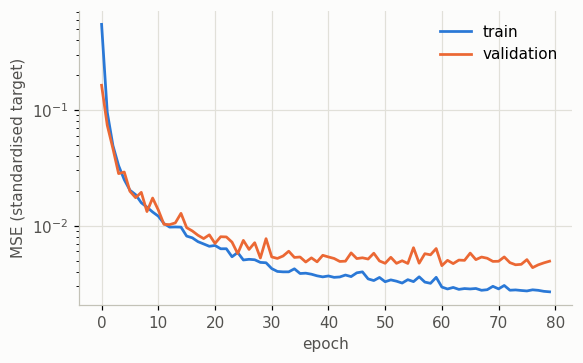

In [33]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(hist_tr, color=BLUE, label="train")
ax.plot(hist_va, color=ORANGE, label="validation")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (standardised target)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"final train {hist_tr[-1]:.5f}  valid {hist_va[-1]:.5f}"
      "  -> both low and together: not overfitting, and more data will not help much")


### Evaluate once, on data the model has never seen

A baseline is not optional. Least squares on **exactly the same 14 encoded features** is the
fair comparison: any gap is then attributable to the nonlinearity, not to better feature
engineering.


In [34]:
# least-squares baseline on the same features
A = torch.cat([x_tr, torch.ones(len(x_tr), 1)], 1)
coef = torch.linalg.lstsq(A, y_tr.unsqueeze(1)).solution
pred_linear = (torch.cat([x_te, torch.ones(len(x_te), 1)], 1) @ coef)[:, 0]

with torch.no_grad():
    pred_mlp = energy_model(x_te)[:, 0] * y_sd + y_mu     # back to watt-hours


def report(name, pred, true):
    err = pred - true
    r2 = 1 - float((err ** 2).sum() / ((true - true.mean()) ** 2).sum())
    print(f"{name:<16}MAE {float(err.abs().mean()):6.3f} Wh   "
          f"RMSE {float((err ** 2).mean().sqrt()):6.3f} Wh   "
          f"R² {r2:6.4f}   MAPE {float((err.abs() / true).mean()) * 100:5.1f} %")


print(f"held-out test set: {len(y_te)} jobs\n")
report("least squares", pred_linear, y_te)
report("MLP 14-32-16-1", pred_mlp, y_te)
print(f"\nsensor noise floor: {0.035 * float(y_te.mean()):.3f} Wh "
      "(3.5 % of the mean job) -- the MLP is close to it")


held-out test set: 750 jobs

least squares   MAE  5.951 Wh   RMSE  9.150 Wh   R² 0.7597   MAPE  74.5 %
MLP 14-32-16-1  MAE  0.895 Wh   RMSE  1.431 Wh   R² 0.9941   MAPE   6.4 %

sensor noise floor: 0.710 Wh (3.5 % of the mean job) -- the MLP is close to it

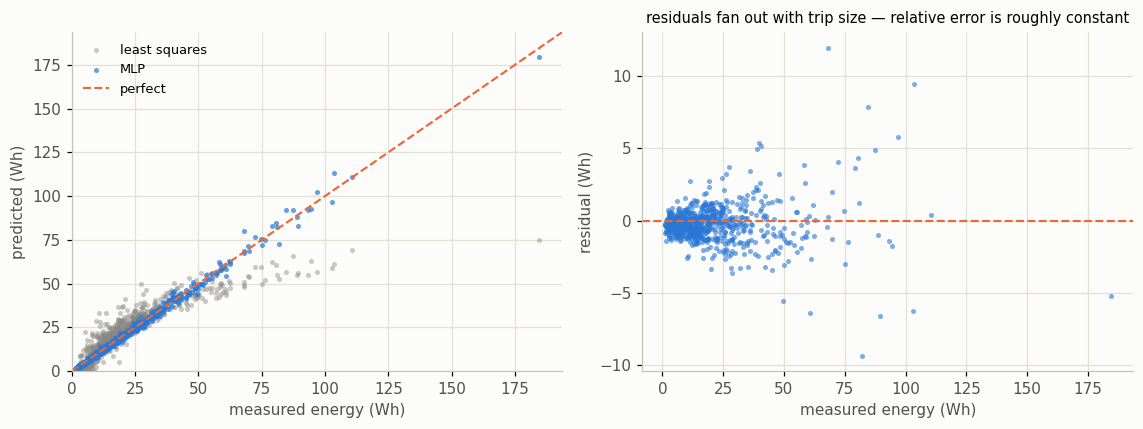

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
ax = axes[0]
lim = [0, float(y_te.max()) * 1.05]
ax.scatter(y_te, pred_linear, s=11, c=MUTED, alpha=.45, lw=0, label="least squares")
ax.scatter(y_te, pred_mlp, s=11, c=BLUE, alpha=.7, lw=0, label="MLP")
ax.plot(lim, lim, color=ORANGE, ls="--", lw=1.4, label="perfect")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("measured energy (Wh)"); ax.set_ylabel("predicted (Wh)")
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1]
ax.scatter(y_te, pred_mlp - y_te, s=11, c=BLUE, alpha=.6, lw=0)
ax.axhline(0, color=ORANGE, lw=1.4, ls="--")
ax.set_xlabel("measured energy (Wh)"); ax.set_ylabel("residual (Wh)")
ax.set_title("residuals fan out with trip size — relative error is roughly constant",
             fontsize=9.5)
plt.tight_layout(); plt.show()


The residual panel is the one to show a fleet manager. The errors grow with trip size, which
means the *relative* error is roughly constant — a per-job energy budget with a percentage
margin is a sound way to use this model, a fixed ±1 Wh margin is not.


cheapest speed in range:  light job 1.90 m/s (at the fast end)   heavy short job 1.19 m/s (a genuine interior minimum)

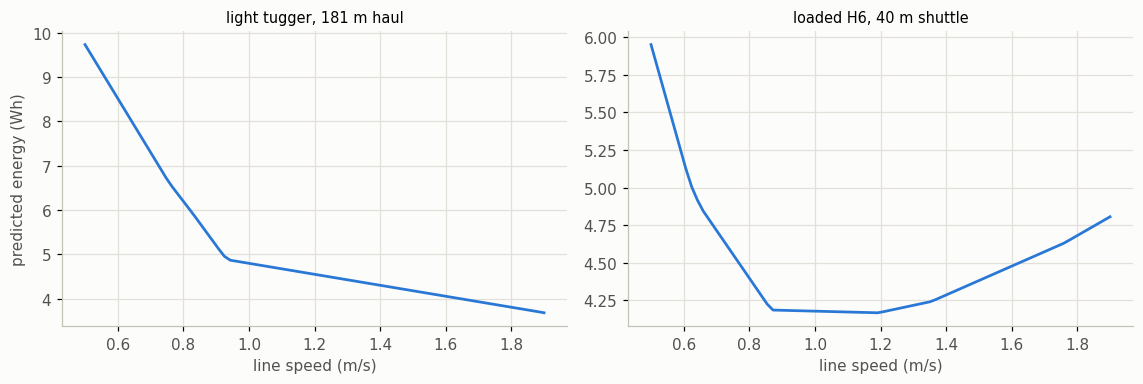

In [36]:
def speed_sweep(row, ax, title):
    '''Predicted energy vs line speed for one job, everything else held fixed.'''
    speeds = np.linspace(0.5, 1.9, 80)
    rows = pd.concat([row] * len(speeds), ignore_index=True)
    rows["speed_mps"] = speeds
    xs, _ = encode(rows)
    with torch.no_grad():
        curve = (energy_model(xs)[:, 0] * y_sd + y_mu).numpy()
    ax.plot(speeds, curve, color=BLUE)
    ax.set_xlabel("line speed (m/s)"); ax.set_title(title, fontsize=9.5)
    return speeds[int(np.argmin(curve))]


light = df_test.iloc[[0]]
heavy = pd.DataFrame([{"payload_kg": 1500.0, "speed_mps": 1.0, "grade_pct": 0.5,
                       "distance_m": 40.0, "battery_age_months": 6.0,
                       "floor_type": "epoxy", "vehicle_model": "H6_heavy",
                       "energy_wh": 0.0}])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
v1 = speed_sweep(light, axes[0], "light tugger, 181 m haul")
v2 = speed_sweep(heavy, axes[1], "loaded H6, 40 m shuttle")
axes[0].set_ylabel("predicted energy (Wh)")
plt.tight_layout(); plt.show()

print(f"cheapest speed in range:  light job {v1:.2f} m/s (at the fast end)   "
      f"heavy short job {v2:.2f} m/s (a genuine interior minimum)")


Neither curve is a straight line, and the two bend in different directions — which is the
whole argument for the nonlinear model in one picture.

Two terms compete. Auxiliaries cost $P_\text{aux}\,d/v$, so **going slower costs more**;
acceleration after every traffic stop costs $\tfrac12 m v^2$ per stop, so **going faster
costs more**. Which one wins depends on the job. For the long, light haul on the left the
auxiliary term dominates across the whole speed range and energy falls monotonically. For
the short, heavily loaded shuttle on the right the mass term takes over and there is a real
minimum inside the operating range — a number a fleet scheduler can act on.

The visible **kinks** are ReLU boundaries: a ReLU network approximates $1/v$ with a
piecewise-linear function, and you are looking at the pieces. A linear model has exactly one
slope available and must be wrong at one end of the range, on both jobs, with the same
coefficient.


---
## 11. The protocol — what to remember

1. **Split before you touch the data.** Every statistic used for preprocessing comes from the
   training split only.
2. **Convert columns by type**: standardise continuous, bucketize ordinal, one-hot or embed
   nominal, then one `torch.cat`.
3. **Parameters are `nn.Parameter` or sub-modules**, never bare tensors or plain lists —
   otherwise they never reach the optimizer.
4. **The loop is four lines**, always in this order:
   `loss.backward()` → `optimizer.step()` → `optimizer.zero_grad()` (and the forward pass
   before them). Gradients accumulate; clearing them is your job.
5. **`torch.no_grad()` for anything that is not training**, and `model.eval()` if any layer
   behaves differently at inference.
6. **Read the learning curves before changing anything.** High-and-flat train loss means
   capacity; a rising validation curve means regularisation. They call for opposite fixes.
7. **Always run a dumb baseline** on the same features. A model that cannot beat least
   squares has not earned its complexity.
8. **Touch the test set once**, at the end, and report the number you got — not the best of
   several.
9. **Quote the noise floor** next to the error. A model at the noise floor is finished; chasing
   it further is chasing measurement error.


---
## 12. Exercises

1. **Bias gradient by hand.** For the one-neuron model of section 4, derive
   $\partial L/\partial b$ from the chain rule on paper, then extend the check to a batch of
   three docking examples. Does autograd return the sum or the mean over the batch? Which does
   `nn.BCELoss` use by default, and what does `reduction="sum"` change?

2. **Break the loop on purpose.** Delete `optimizer.zero_grad()` from `train_dock` and plot
   the loss. Then move it *before* `loss.backward()` instead of after `optimizer.step()`, and
   explain why that version still works.

3. **Capacity vs optimisation.** The flat model fails at 59 %. Prove the failure is capacity,
   not optimisation, by (a) training it for 4000 epochs, (b) trying `lr` in
   {0.005, 0.05, 0.5}, and (c) adding the single engineered feature $x_1x_2$ to the input and
   retraining the *same* 3-parameter architecture. Report all three.

4. **Activation study.** Replace `ReLU` with `Tanh`, `LeakyReLU` and `ELU` in
   `build_dock_model([8, 8])`, three seeds each, and tabulate the final validation accuracy
   and the epoch at which it first exceeds 90 %. Which changes — the ceiling or the speed?

5. **A custom layer that earns its keep.** Write `PhysicsFeatures(nn.Module)` whose `forward`
   appends the products `payload × distance`, `payload × grade` and `distance / speed` to the
   14 encoded features, then train the same MLP on the 17 columns. Does the extra information
   reduce the test MAE, or was the network already reconstructing those products?

6. **Embeddings.** Replace the two one-hot blocks with `nn.Embedding(3, 2)` each and compare
   the test MAE and the parameter count. Then print the learned 2-D vectors for the three
   vehicle models — do they order themselves by tare mass?

7. **Leakage, measured.** Recompute `stats` on the *whole* `fleet` frame instead of
   `df_train`, retrain, and report the test MAE. How large is the optimistic bias here, and why
   is it small for standardisation but potentially huge for, say, target encoding of a
   categorical column?

8. **Deploy it.** Save the trained `energy_model` with `torch.save(model.state_dict(), ...)`,
   reload it into a fresh module, confirm the predictions match bit for bit, and measure the
   single-sample inference latency with `time.perf_counter`. The fleet controller re-plans at
   10 Hz — what fraction of that 100 ms budget does one prediction use?


---
## 13. References

**Book chapter this lecture follows**

* Raschka, S., Liu, Y. & Mirjalili, V. (2022). *Machine Learning with PyTorch and
  Scikit-Learn*, Chapter 13: "Going Deeper — The Mechanics of PyTorch". Packt.

**Papers**

* Glorot, X. & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward
  neural networks. *AISTATS 2010*, PMLR 9:249–256.
  <http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf>
* He, K., Zhang, X., Ren, S. & Sun, J. (2015). Delving deep into rectifiers: surpassing
  human-level performance on ImageNet classification. *ICCV 2015*. (He initialisation, the
  ReLU-adapted counterpart of Glorot.)
* Baydin, A. G., Pearlmutter, B. A., Radul, A. A. & Siskind, J. M. (2018). Automatic
  differentiation in machine learning: a survey. *JMLR* 18(153):1–43.
* Paszke, A. et al. (2019). PyTorch: an imperative style, high-performance deep learning
  library. *NeurIPS 2019*. (The design rationale for the dynamic graph.)
* Hornik, K., Stinchcombe, M. & White, H. (1989). Multilayer feedforward networks are
  universal approximators. *Neural Networks* 2(5):359–366.
* Minsky, M. & Papert, S. (1969). *Perceptrons*. MIT Press. (The original XOR argument.)
* Kingma, D. P. & Ba, J. (2015). Adam: a method for stochastic optimization. *ICLR 2015*.
* Lutter, M., Ritter, C. & Peters, J. (2019). Deep Lagrangian Networks: using physics as model
  prior for deep learning. *ICLR 2019*. (Physics-informed layers for robot dynamics —
  the direction exercise 5 points at.)

**Documentation**

* Autograd mechanics — <https://pytorch.org/docs/stable/notes/autograd.html>
* `torch.nn` — <https://pytorch.org/docs/stable/nn.html>
* `torch.nn.init` — <https://pytorch.org/docs/stable/nn.init.html>
* `torch.optim` — <https://pytorch.org/docs/stable/optim.html>
* Saving and loading models — <https://pytorch.org/tutorials/beginner/saving_loading_models.html>

**Domain background**

* VDI 2510 / VDMA guidance on AGV systems; ISO 3691-4:2020, *Industrial trucks — Safety
  requirements: driverless industrial trucks and their systems*.
* Ehsani, M., Gao, Y., Longo, S. & Ebrahimi, K. (2018). *Modern Electric, Hybrid Electric and
  Fuel Cell Vehicles*, 3rd ed. CRC Press. (The road-load equation used by the generator.)


Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>